In [1]:
import pandas_datareader.data as web
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [2]:
cd = ['SPY', 'SPXL']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
df.tail()

Symbols,SPY,SPXL
Date,,
2020-10-05,339.76,54.85
2020-10-06,334.93,52.56
2020-10-07,340.76,55.23
2020-10-08,343.78,56.69
2020-10-09,346.85,58.22


In [3]:
df.iloc[:,1]

Date
2019-01-02    32.58
2019-01-03    30.17
2019-01-04    33.21
2019-01-07    34.01
2019-01-08    34.93
              ...  
2020-10-05    54.85
2020-10-06    52.56
2020-10-07    55.23
2020-10-08    56.69
2020-10-09    58.22
Name: SPXL, Length: 448, dtype: float64

In [4]:
def coint_test(df):
    df.dropna(inplace=True)
    X = df[cd[0]]
    Y = df[cd[1]]
    (Y/X).plot(figsize=(15,5))
    plt.axhline((Y/X).mean(), color='red', linestyle='--')
    plt.xlabel('Time')
    plt.legend(['Price Ratio', 'Mean'])
    plt.show()
    score, pvalue, _ = coint(X,Y)
    print('Correlation: {:.4f}'.format(X.corr(Y)))
    print('Cointegration test p-value: {:.4}'.format(pvalue))

In [5]:
def compare_chart(df):
    fig, ax1 = plt.subplots(figsize=(15,5), facecolor='silver')
    ax1.plot(df.iloc[:,0]/df.iloc[0,0], color='crimson', label='X')
    ax2 = ax1.twinx()
    ax2.plot(df.iloc[:,1]/df.iloc[0,1], color='dodgerblue', label='Y')
    fig.legend()
    plt.show()

In [6]:
def compare_chart(df):
    fig = plt.figure(figsize=(15,5), facecolor='silver')
    plt.plot(df.iloc[:,0]/df.iloc[0,0], color='crimson', label='X')
    plt.plot(df.iloc[:,1]/df.iloc[0,1], color='dodgerblue', label='Y')
    plt.show()

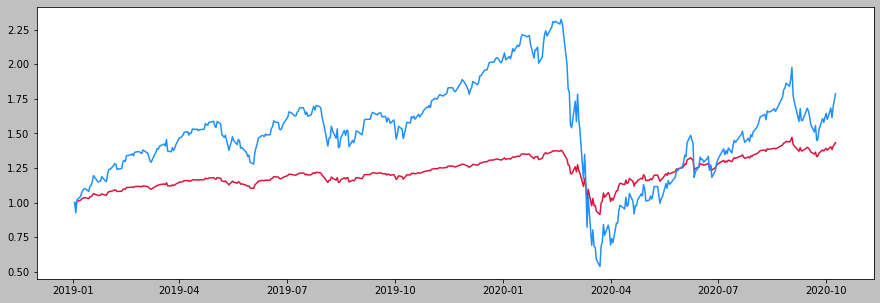

In [7]:
compare_chart(df)

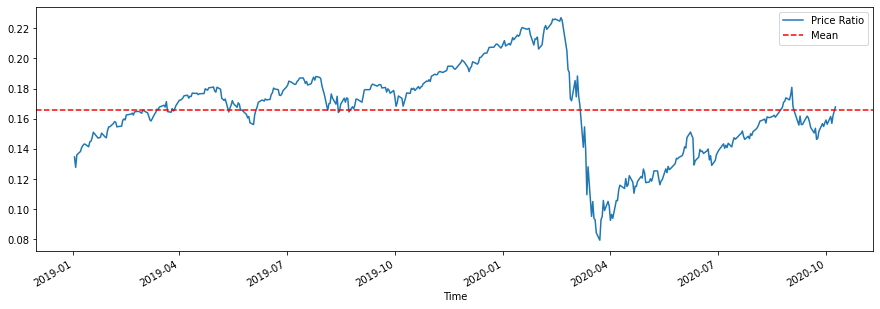

Correlation: 0.7194
Cointegration test p-value: 0.9912


In [8]:
coint_test(df)

In [9]:
# rtn = (1 + df.pct_change()) # 일일수익률
rtn = df
rtn = rtn.dropna()
rtn = rtn.tail(100)  

X = rtn[cd[0]]
Y = rtn[cd[1]]

In [10]:
def coint_price(df):
    # rtn = ((df.pct_change()+1)*100).dropna()
    # rtn = np.log(df).dropna()
    df.dropna(inplace=True)
    X = df[cd[0]]
    Y = df[cd[1]]
    coint_p_value = coint(X,Y)    # 공적분: 시계열이 관계가 없을 확률
    rst = {}
    rst['corr'] = X.corr(Y).round(4)    # 상관관계
    rst['p-value'] = round(coint_p_value[1], 4)    # 시계열이 관계가 있을 확률
    return rst

In [11]:
def coint_rtn(df):
    df = ((df.pct_change()+1)*100).dropna()
    X = df[cd[0]]
    Y = df[cd[1]]
    coint_p_value = coint(X,Y)[1]    # 공적분: 시계열이 관계가 없을 확률
    rst = {}
    rst['corr'] = X.corr(Y).round(4)    # 상관관계
    rst['p-value'] = round(coint_p_value, 4)    # 시계열이 관계가 있을 확률
    return rst

{'corr': 0.9997, 'p-value': 0.0996}
{'corr': 0.9974, 'p-value': 0.0}


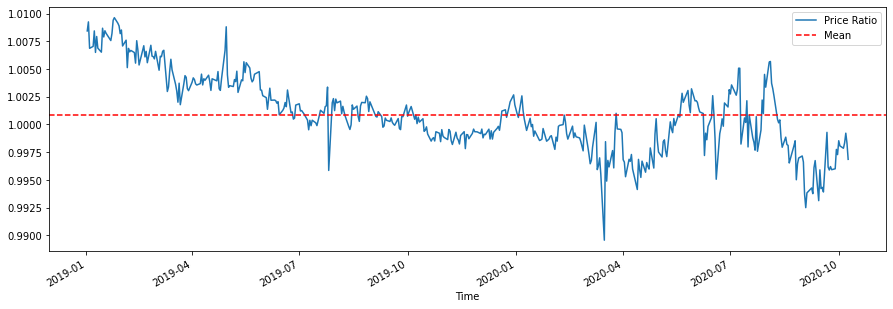

Correlation: 0.9997
Cointegration test p-value: 0.09961


In [12]:
cd = ['GOOG', 'GOOGL']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
print(coint_price(df))
print(coint_rtn(df))
coint_test(df)

{'corr': -0.642, 'p-value': 0.0722}
{'corr': 0.3349, 'p-value': 0.0}


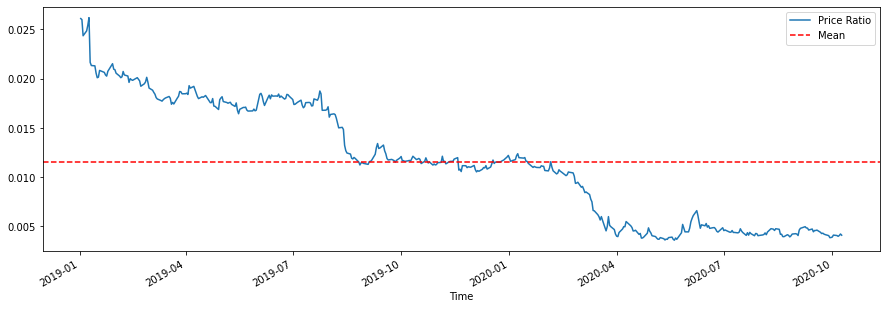

Correlation: -0.6420
Cointegration test p-value: 0.07222


In [13]:
cd = ['GOOG', 'M']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
print(coint_price(df))
print(coint_rtn(df))
coint_test(df)

{'corr': 0.8399, 'p-value': 0.2474}
{'corr': 0.8806, 'p-value': 0.0}


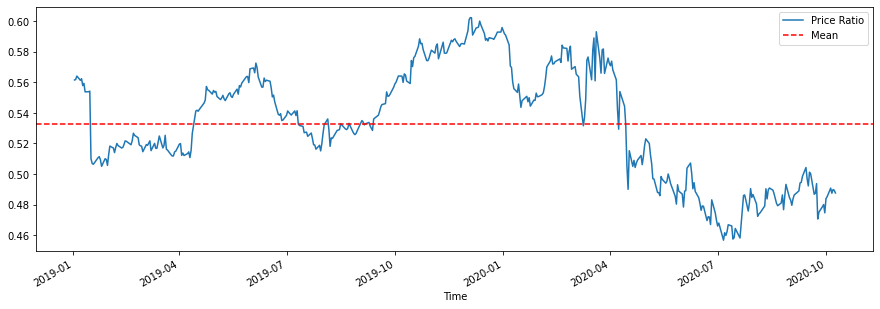

Correlation: 0.8399
Cointegration test p-value: 0.2474


In [14]:
cd = ['GS', 'JPM']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
print(coint_price(df))
print(coint_rtn(df))
coint_test(df)

{'corr': -0.6996, 'p-value': 0.8568}
{'corr': 0.2082, 'p-value': 0.0}


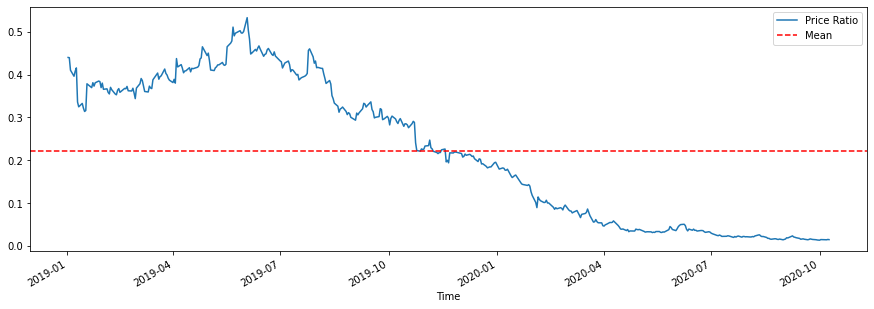

Correlation: -0.6996
Cointegration test p-value: 0.8568


In [15]:
cd = ['TSLA', 'M']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
print(coint_price(df))
print(coint_rtn(df))
coint_test(df)

{'corr': 0.7194, 'p-value': 0.9912}
{'corr': 0.9995, 'p-value': 0.0}


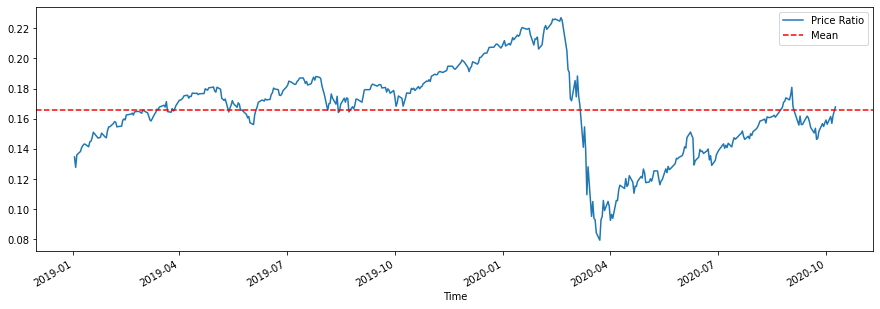

Correlation: 0.7194
Cointegration test p-value: 0.9912


In [16]:
cd = ['SPY', 'SPXL']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
print(coint_price(df))
print(coint_rtn(df))
coint_test(df)

{'corr': 1.0, 'p-value': 0.0095}
{'corr': 0.9988, 'p-value': 0.0001}


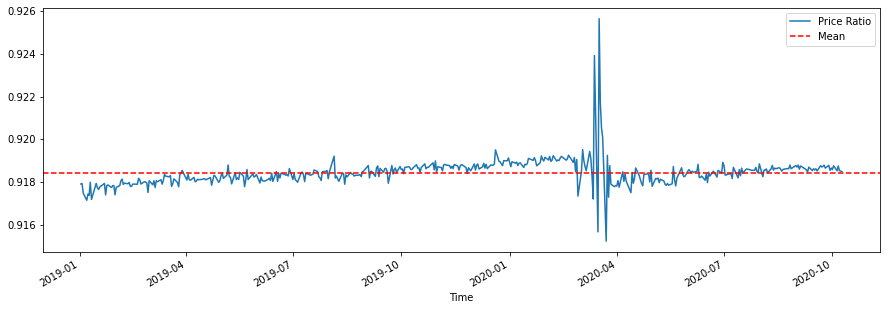

Correlation: 1.0000
Cointegration test p-value: 0.009513


In [17]:
cd = ['SPY', 'VOO']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
print(coint_price(df))
print(coint_rtn(df))
coint_test(df)

{'corr': 0.9967, 'p-value': 0.0151}
{'corr': 0.9844, 'p-value': 0.0}


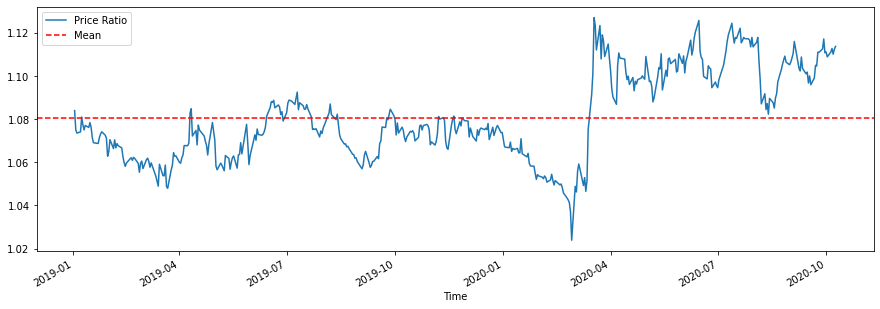

Correlation: 0.9967
Cointegration test p-value: 0.01512


In [18]:
cd = ['DISCK', 'DISCA']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
print(coint_price(df))
print(coint_rtn(df))
coint_test(df)

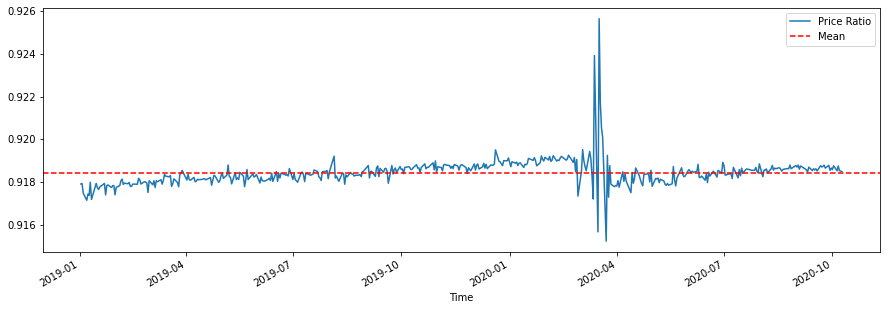

Correlation: 1.0000
Cointegration test p-value: 0.009513


In [20]:
cd = ['SPY', 'VOO']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
coint_test(df)

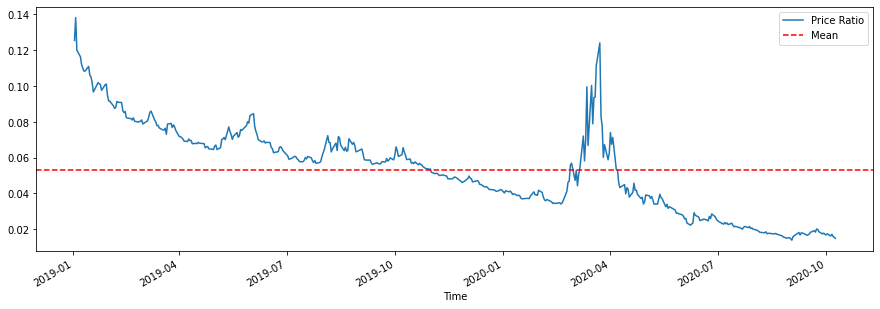

Correlation: -0.8526
Cointegration test p-value: 0.4816


In [21]:
cd = ['SPY', 'SPXS']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
coint_test(df)

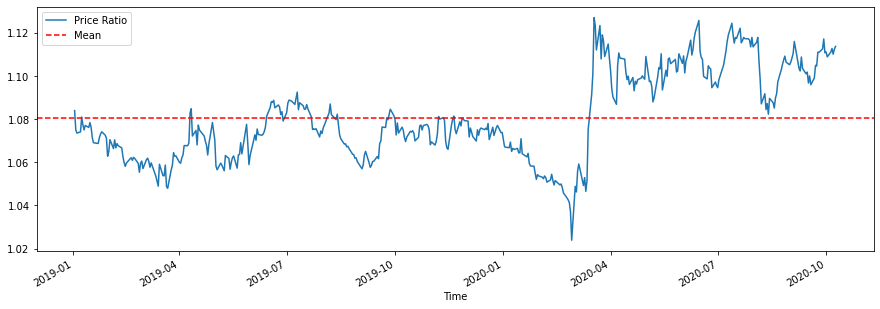

Correlation: 0.9967
Cointegration test p-value: 0.01512


In [22]:
cd = ['DISCK', 'DISCA']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)
coint_test(df)

In [ ]:
X = df[cd[0]]
Y = df[cd[1]]
co_integration = coint(X,Y)[1]
print('Correlation: {}'.format(X.corr(Y)))
print('Cointegration test p-value: {}'.format(co_integration))   # 관계가 없을 확률
# If the pvalue is small, below a critical size, then we can reject the hypothesis that there is no cointegrating relationship.

In [ ]:
coint(X,Y)

In [ ]:
cd = ['GOOG', 'M']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)

X = df[cd[0]]
Y = df[cd[1]]
co_integration = coint(X,Y)[1]
print('Correlation: {}'.format(X.corr(Y)))
print('Cointegration test p-value: {}'.format(co_integration))    # 관계가 없을 확률

In [ ]:
cd = ['DISCK', 'DISCA']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)

X = df[cd[0]]
Y = df[cd[1]]
co_integration = coint(X,Y)[1]
print('Correlation: {}'.format(X.corr(Y)))
print('Cointegration test p-value: {}'.format(co_integration))    # 관계가 없을 확률

In [ ]:
cd = ['GS', 'JPM']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)

X = df[cd[0]]
Y = df[cd[1]]
co_integration = coint(X,Y)[1]
print('Correlation: {}'.format(X.corr(Y)))
print('Cointegration test p-value: {}'.format(co_integration))    # 관계가 없을 확률

In [ ]:
cd = ['SPY', 'VOO']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)

X = df[cd[0]]
Y = df[cd[1]]
co_integration = coint(X,Y)[1]
print('Correlation: {}'.format(X.corr(Y)))
print('Cointegration test p-value: {}'.format(co_integration))    # 관계가 없을 확률

In [ ]:
cd = ['SPY', 'SPXS']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)

X = df[cd[0]]
Y = df[cd[1]]
co_integration = coint(X,Y)[1]
print('Correlation: {:.4f}'.format(X.corr(Y)))
print('Cointegration test p-value: {:.4f}'.format(co_integration))    # 관계가 없을 확률

In [ ]:
cd = ['SPY', 'SPXL']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)

X = df[cd[0]]
Y = df[cd[1]]
co_integration = coint(X,Y)[1]
print('Correlation: {:.4f}'.format(X.corr(Y)))
print('Cointegration test p-value: {:.4f}'.format(co_integration))    # 관계가 없을 확률

In [ ]:
cd = ['SPY', 'SPXL']
df = web.DataReader(cd, 'yahoo', start='2019-01-01')['Adj Close'].round(2)

X = df[cd[0]].pct_change()+1
Y = df[cd[1]].pct_change()+1
X.dropna(inplace=True)
Y.dropna(inplace=True)
co_integration = coint(X,Y)[1]
print('Correlation: {:.4f}'.format(X.corr(Y)))
print('Cointegration test p-value: {:.4f}'.format(co_integration))    # 관계가 없을 확률

In [ ]:
coint_calulator(df)

In [ ]:
(df[cd[1]].pct_change()+1).min()

In [ ]:
df[cd[1]].pct_change()

In [ ]:
df[pd.isna(df[cd[1]].pct_change())==True]